In [44]:
import sys
import os

PROJECT_ROOT = r"C:\Users\mniu\Documents\neuroblastoma-multiome"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

import importlib
import preprocessing
importlib.reload(preprocessing)
from preprocessing import preprocess_rna
print("Import successful!")

Import successful!


In [45]:
adata_be2c = preprocess_rna(filepath = os.path.join(PROJECT_ROOT, "data", "raw", "GSM8159271_Be2c_filtered_feature_bc_matrix.h5"),
                            cell_line_name = "Be2c", project_root = PROJECT_ROOT)
print(adata_be2c)


Processing: Be2c
Loaded: (18473, 36601)
Scrublet predicted doublets: 1
After filtering: (16818, 28110)
HVGs: 2721
Clusters: 9
Saving to: C:\Users\mniu\Documents\neuroblastoma-multiome\data\processed\Be2c_rna_processed.h5ad
Saved successfully: True
AnnData object with n_obs × n_vars = 16818 × 2721
    obs: 'cell_line', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'leiden', 'umap', 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


## Week 3 Day 1 - Generalized RNA Pipeline

Converted the Be2c RNA preprocessing steps from Week 2 into a reusable function in src/preprocessing.py. Kep design decisions:

- Parameters are exposed as arguments with Be2c-optimized defaults (min_genes = 1000, max_counts = 100000, pct_mt_max = 20) so individual cell lines can use different thresholds if needed
- cell_line_name is stored in adata.obs['cell_line'] for every cell, enabling later concatenation of all 6 cell lines into one object
- Scrublet runs in a try/except block so it doesn't crash the pipeline if the install is unavailable on another machine
- adata.raw checkpoint preserved before HVG subsetting
- Output saved to data/processed/{cell_line_name}_rna_processed.h5ad

Function tested on Be2c and reproduces week 2 results

In [46]:
import sys
import os

PROJECT_ROOT = r"C:\Users\mniu\Documents\neuroblastoma-multiome"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

import importlib
import preprocessing
importlib.reload(preprocessing)
from preprocessing import preprocess_rna

In [47]:
raw_dir = os.path.join(PROJECT_ROOT, "data", "raw")
print("Files in data/raw/:")
for f in os.listdir(raw_dir):
    print(f" {f}")

Files in data/raw/:
 GSM8159270_Be2c_atac.h5ad
 GSM8159270_count_matrix_Be2c_atac.csv
 GSM8159271_Be2c_filtered_feature_bc_matrix.h5
 GSM8159273_CHP134_filtered_feature_bc_matrix.h5
 GSM8159275_SHSY5Y_filtered_feature_bc_matrix.h5
 GSM8159277_SK.N.AS_filtered_feature_bc_matrix.h5
 GSM8159279_SK.N.DZ_filtered_feature_bc_matrix.h5
 GSM8159281_SK.N.SH_filtered_feature_bc_matrix.h5


In [48]:
# only h5 files
h5_files = [f for f in os.listdir(raw_dir) if f.endswith("h5")]
print("H5 files found:")
for f in h5_files:
    print(f" {f}")

H5 files found:
 GSM8159271_Be2c_filtered_feature_bc_matrix.h5
 GSM8159273_CHP134_filtered_feature_bc_matrix.h5
 GSM8159275_SHSY5Y_filtered_feature_bc_matrix.h5
 GSM8159277_SK.N.AS_filtered_feature_bc_matrix.h5
 GSM8159279_SK.N.DZ_filtered_feature_bc_matrix.h5
 GSM8159281_SK.N.SH_filtered_feature_bc_matrix.h5


In [49]:
# Full pipeline on all 6 cell lines
cell_lines = {
    "Be2c": "GSM8159271_Be2c_filtered_feature_bc_matrix.h5",
    "CHP134": "GSM8159273_CHP134_filtered_feature_bc_matrix.h5",
    "SHSY5Y": "GSM8159275_SHSY5Y_filtered_feature_bc_matrix.h5",
    "SKNAS": "GSM8159277_SK.N.AS_filtered_feature_bc_matrix.h5",
    "SKNDZ": "GSM8159279_SK.N.DZ_filtered_feature_bc_matrix.h5",
    "SKNSH": "GSM8159281_SK.N.SH_filtered_feature_bc_matrix.h5"
}

results = {}
failed = []
for cell_line, filename in cell_lines.items():
    filepath = os.path.join(PROJECT_ROOT, "data", "raw", filename)
    if not os.path.exists(filepath):
        print(f"SKIPPING {cell_line} - file not found: {filepath}")
        failed.append(cell_line)
        continue
    try:
        results[cell_line] = preprocess_rna(filepath = filepath, cell_line_name = cell_line, project_root = PROJECT_ROOT)
    except Exception as e:
        print(f"ERROR processing {cell_line}: {e}")
        failed.append(cell_line)

print(f"\nSuccessfully processed: {list(results.keys())}")
if failed:
    print(f"Failed/skipped: {failed}")


Processing: Be2c
Loaded: (18473, 36601)
Scrublet predicted doublets: 1
After filtering: (16818, 28110)
HVGs: 2721
Clusters: 9
Saving to: C:\Users\mniu\Documents\neuroblastoma-multiome\data\processed\Be2c_rna_processed.h5ad
Saved successfully: True

Processing: CHP134
Loaded: (7275, 36601)
Scrublet predicted doublets: 0
After filtering: (7068, 27027)
HVGs: 2288
Clusters: 10
Saving to: C:\Users\mniu\Documents\neuroblastoma-multiome\data\processed\CHP134_rna_processed.h5ad
Saved successfully: True

Processing: SHSY5Y
Loaded: (6446, 36601)
Scrublet predicted doublets: 0
After filtering: (5952, 28035)
HVGs: 4133
Clusters: 10
Saving to: C:\Users\mniu\Documents\neuroblastoma-multiome\data\processed\SHSY5Y_rna_processed.h5ad
Saved successfully: True

Processing: SKNAS
Loaded: (9022, 36601)
Scrublet predicted doublets: 1
After filtering: (8225, 27237)
HVGs: 2993
Clusters: 8
Saving to: C:\Users\mniu\Documents\neuroblastoma-multiome\data\processed\SKNAS_rna_processed.h5ad
Saved successfully: Tru

In [50]:
# summary table

import pandas as pd

summary = []
for cl, adata in results.items():
    summary.append({
        "cell_line": cl,
        "MYCN": "amplified" if cl in ["Be2c", "CHP134", "SKNDZ"] else "non-amplified",
        "cells_after_filtering": adata.n_obs,
        "HVGs": adata.var.shape[0],
        "clusters": adata.obs["leiden"].nunique()
    })

df = pd.DataFrame(summary)
print(df.to_string(index = False))

cell_line          MYCN  cells_after_filtering  HVGs  clusters
     Be2c     amplified                  16818  2721         9
   CHP134     amplified                   7068  2288        10
   SHSY5Y non-amplified                   5952  4133        10
    SKNAS non-amplified                   8225  2993         8
    SKNDZ     amplified                   6060  3816        11
    SKNSH non-amplified                   6720  4069        12


In [51]:
# verify files saved
processed_dir = os.path.join(PROJECT_ROOT, "data", "processed")
print("Processed files:")
for f in os.listdir(processed_dir):
    print(f" {f}")

Processed files:
 Be2c_rna_processed.h5ad
 CHP134_rna_processed.h5ad
 SHSY5Y_rna_processed.h5ad
 SKNAS_rna_processed.h5ad
 SKNDZ_rna_processed.h5ad
 SKNSH_rna_processed.h5ad
 test


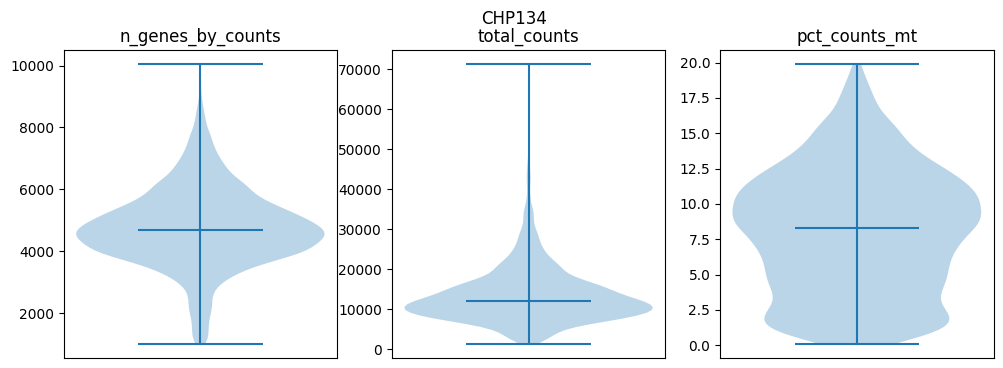

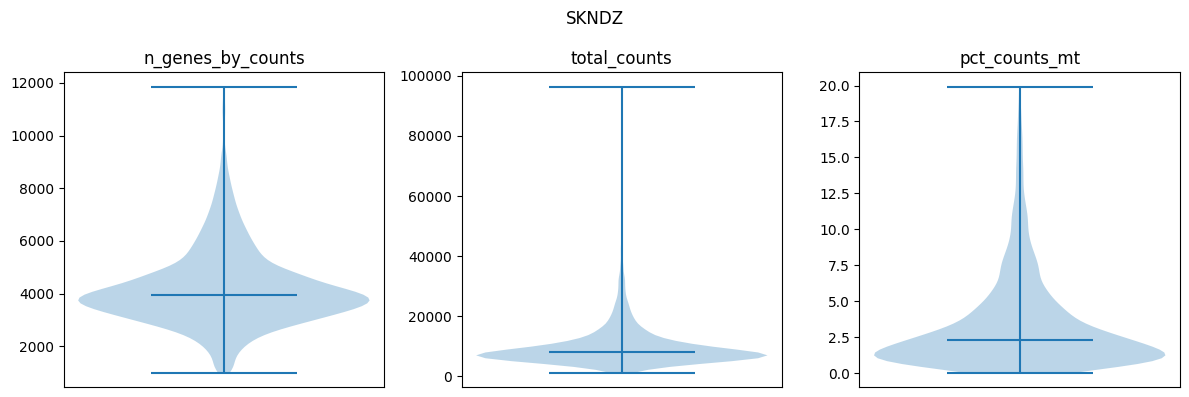

In [52]:
import matplotlib.pyplot as plt

# violin plot check
for cl in ["CHP134", "SKNDZ"]:
    adata = results[cl]
    fig, axes = plt.subplots(1, 3, figsize = (12, 4))
    fig.suptitle(cl)

    for ax, metric in zip(axes, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']):
        data = adata.obs[metric].values
        ax.violinplot(data, showmedians=True)
        ax.set_title(metric)
        ax.set_xticks([])

plt.tight_layout()
plt.show()

Created: C:\Users\mniu\Documents\neuroblastoma-multiome\outputs\figures


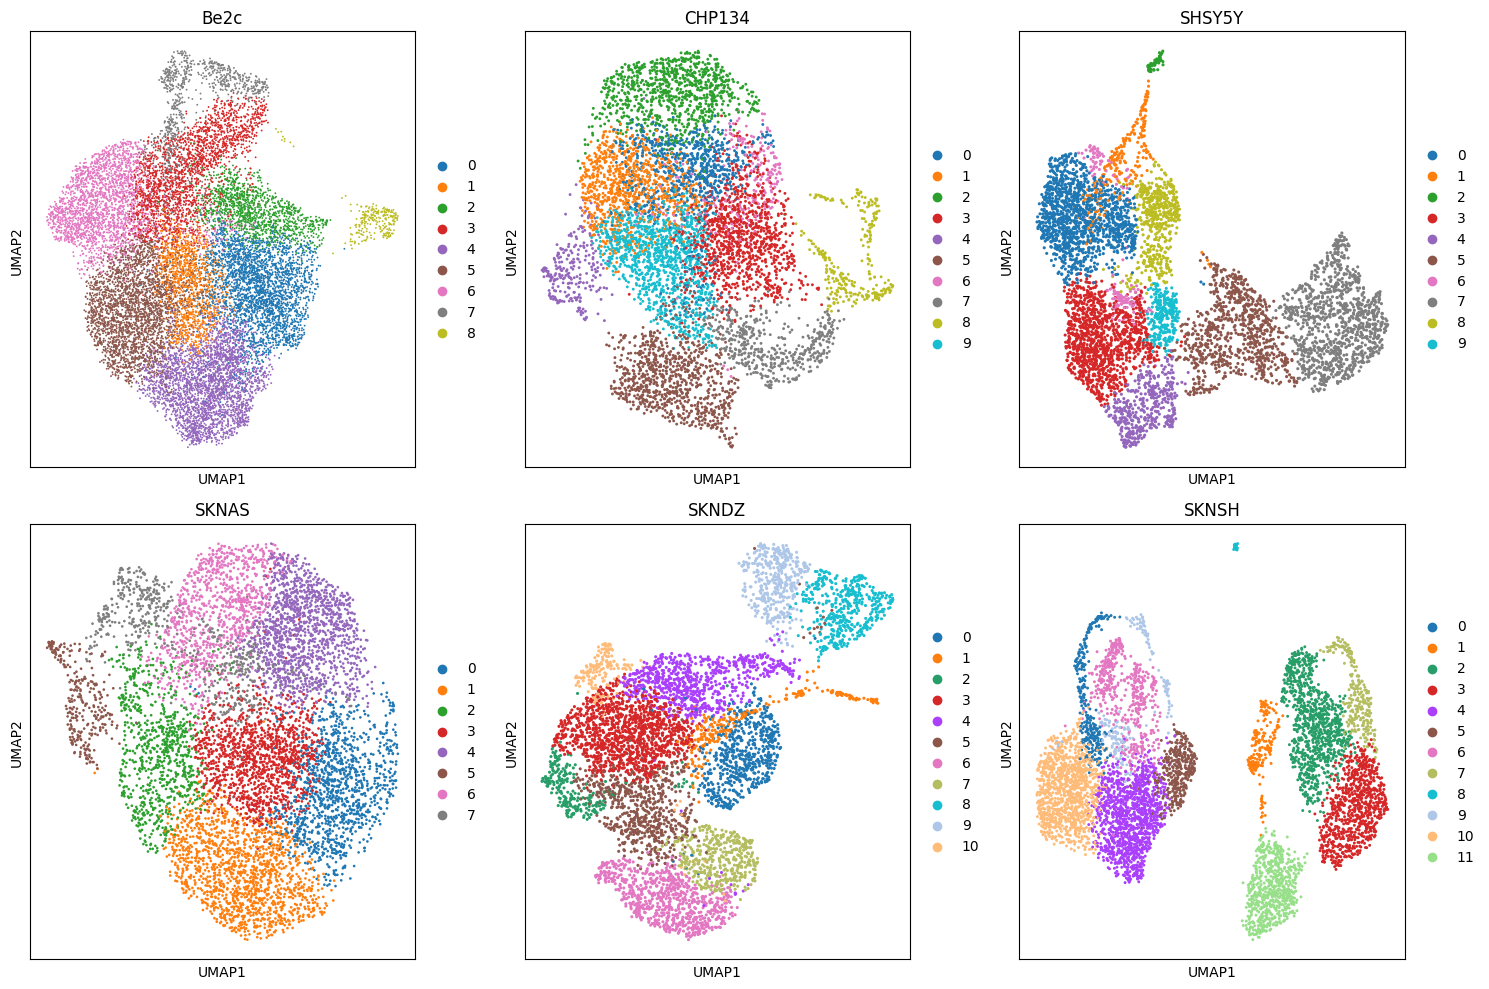

In [53]:
# check UMAP
import scanpy as sc

figures_dir = os.path.join(PROJECT_ROOT, "outputs", "figures")
os.makedirs(figures_dir, exist_ok = True)
print(f"Created: {figures_dir}")

fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes = axes.flatten()

for i, (cl, adata) in enumerate(results.items()):
    sc.pl.umap(adata, color = 'leiden', title = cl, ax = axes[i], show = False)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "outputs", "figures", "all_cell_lines_umap.png"), dpi = 150, bbox_inches = 'tight')
plt.show()

In [54]:
# Check SHSY5Y isolated cluster
shsy5y = results["SHSY5Y"]
qc_shsy5y = shsy5y.obs.groupby('leiden', observed = True)[['pct_counts_mt', 'total_counts', 'n_genes_by_counts']].mean()
print("SHSY5Y clusters:")
print(qc_shsy5y.sort_values('n_genes_by_counts', ascending = False))

# SKNSH outlier dot
sknsh = results["SKNSH"]
print("\nSKNSH cluster sizes:")
print(sknsh.obs['leiden'].value_counts())

SHSY5Y clusters:
        pct_counts_mt  total_counts  n_genes_by_counts
leiden                                                
7           13.499325  32399.892578        7258.838432
4            7.710051  14134.826172        5133.529680
5           13.345738  14804.270508        4931.131514
3            9.453502  11014.653320        4456.787177
9            7.634023   9551.809570        4179.103053
0           10.025443   8847.122070        3822.335616
6            6.638012   7840.443848        3704.629139
8            7.983865   7962.950195        3606.609195
1            8.461959   7063.797363        3464.595041
2           12.104671   8483.770508        3101.854167

SKNSH cluster sizes:
leiden
4     1254
10    1085
2      985
3      843
11     695
6      513
5      367
0      300
7      269
1      195
9      193
8       21
Name: count, dtype: int64


In [55]:
# Check SKNSH cluster 8 with only 21 cells
sknsh = results["SKNSH"]
print(sknsh.obs.groupby('leiden', observed = True)[['pct_counts_mt', 'total_counts', 'n_genes_by_counts']].mean().loc[['8']])

        pct_counts_mt  total_counts  n_genes_by_counts
leiden                                                
8            1.485002   3259.952393        1366.238095


## Week 3 Day 2 - All 6 Cell Lines RNA Preprocessing

### Pipeline
Applied the generalized 'preprocess_rna()' function from 'src/preprocessing.py' to all 6 neuroblastoma cell lines using consistent parameters: min_genes = 1000, max_counts = 100000, pct_mt < 20%, n_neighbors = 15, n_pcs = 15, leiden_resolution = 0.5.

### Summary Table

| Cell Line | MYCN | Cells | HVGS | Clusters |
| --- | --- | --- | --- | --- |
| Be2c | Amplified | 16818 | 2721 | 9 |
| CHP134 | Amplified | 7068 | 2288 | 10 |
| SHSY5Y | Non-amplified | 5952 | 4133 | 10 |
| SKNAS | Non-amplified | 8225 | 2993 | 8 |
| SKNDZ | Amplified | 6060 | 3816 | 11 |
| SKNSH | Non-amplified | 6720 | 4069 | 12 |

### Key Observations
- Be2c has ~2.4 more cells than any other line - potential batch effect concern for downstream integration
- Non-amplified lines (SHSY5Y, SKNSH) have notable more HVGs (~4000) vs amplified lines (~2300 - 3800), possibly reflecting differences in transcriptional diversity between MYCN status groups
- CHP134 shows highest MT% (median ~8%) of all cell lines
- SKNDZ has the cleanest QC profile (median MT% ~2%) and most distinct cluster separation in UMAP space
- SHSY5Y cluster 7: unusual high MT% (13.5%) combined with high gene complexity (7258) genes/cell) - may reflect active mitochondrial metabolism rather than low quality; retained pending further investigation
- SKNSH cluster 8 (n = 21): very small isolated cluster with low MT% (1.49%), low total_counts (3260), and low n_genes_by_counts (1366) - just above the min_genes = 1000 filter threshold. Likely represents borderline low-quality or quiescent cells. Too small (n = 21) to draw biological conclusions from, retained but flagged as a caveat for downstream integration.
- CHP134 UMAP shows elongated branching structure suggesting a possible differentiation continuum rather than discrete cell states

In [56]:
processed_dir = os.path.join(PROJECT_ROOT, "data", "processed")
print("Processed files:")
for f in sorted(os.listdir(processed_dir)):
    if f.endswith(".h5ad"):
        size_mb = os.path.getsize(os.path.join(processed_dir, f)) / (1024*1024)
        print(f" {f}: {size_mb:.1f} MB")

Processed files:
 Be2c_rna_processed.h5ad: 171.6 MB
 CHP134_rna_processed.h5ad: 86.2 MB
 SHSY5Y_rna_processed.h5ad: 79.5 MB
 SKNAS_rna_processed.h5ad: 98.9 MB
 SKNDZ_rna_processed.h5ad: 70.8 MB
 SKNSH_rna_processed.h5ad: 87.3 MB


In [57]:
processed_dir = os.path.join(PROJECT_ROOT, "data", "processed")
for f in sorted(os.listdir(processed_dir)):
    if f.endswith(".h5ad"):
        size_mb = os.path.getsize(os.path.join(processed_dir, f)) / (1024 * 1024)
        adata_test = sc.read_h5ad(os.path.join(processed_dir, f))
        print(f"{f}: {size_mb:.1f} MB, {adata_test.shape}, clusters: {adata_test.obs['leiden'].nunique()}")

Be2c_rna_processed.h5ad: 171.6 MB, (16818, 2721), clusters: 9
CHP134_rna_processed.h5ad: 86.2 MB, (7068, 2288), clusters: 10
SHSY5Y_rna_processed.h5ad: 79.5 MB, (5952, 4133), clusters: 10
SKNAS_rna_processed.h5ad: 98.9 MB, (8225, 2993), clusters: 8
SKNDZ_rna_processed.h5ad: 70.8 MB, (6060, 3816), clusters: 11
SKNSH_rna_processed.h5ad: 87.3 MB, (6720, 4069), clusters: 12
